In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, log_loss, roc_auc_score,
    roc_curve, auc, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ==============================
# 2. LOAD DATA
# ==============================
train_df = pd.read_excel(
    "/content/drive/MyDrive/CBC Data/CBC indices data set/5778-Non-SMOTE-NC.xlsx"
)

test_df = pd.read_excel(
    "/content/drive/MyDrive/CBC Data/CBC indices data set/625-External data.xlsx"
)

In [5]:
# ==============================
# 3. CLEAN
# ==============================
def clean(df):
    df.columns = df.columns.str.strip().str.upper()
    return df

train_df = clean(train_df)
test_df  = clean(test_df)

drop_cols = ['NO','SEX','AGE']
train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
test_df  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

In [6]:
# ==============================
# 4. FEATURE ENGINEERING
# ==============================
def fe(df):
    df = df.copy()
    eps = 1e-6
    df['MENTZER'] = df['MCV']/(df['RBC']+eps)
    df['RDW_MCV'] = df['RDW']/(df['MCV']+eps)
    df['MCV_RBC'] = df['MCV']/(df['RBC']+eps)
    df['MCH_MCV'] = df['MCH']/(df['MCV']+eps)
    return df

train_df = fe(train_df)
test_df  = fe(test_df)

In [7]:
# ==============================
# 5. FEATURES
# ==============================
features = [
    'RBC','MCV','MCH','RDW','HGB','HCT',
    'MENTZER','RDW_MCV','MCV_RBC','MCH_MCV'
]

TARGET = 'LABEL'

X = train_df[features]
y = train_df[TARGET]

X_test = test_df[features]
y_test = test_df[TARGET]

In [8]:
# ==============================
# 6. SPLIT
# ==============================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [9]:
# ==============================
# 🔥 7. SMOTE (ONLY TRAIN)
# ==============================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [10]:
# ==============================
# 🔥 8. SCALING (CRITICAL FOR MLP)
# ==============================
scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_sm)
X_val      = scaler.transform(X_val)
X_test     = scaler.transform(X_test)
X_train    = scaler.transform(X_train)

In [11]:
# ==============================
# 🔥 9. MODEL (MLP)
# ==============================
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2-layer network
    activation='relu',
    solver='adam',
    alpha=0.001,                  # regularization
    learning_rate='adaptive',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

model.fit(X_train_sm, y_train_sm)

MLPClassifier(alpha=0.001, early_stopping=True, hidden_layer_sizes=(64, 32),
              learning_rate='adaptive', max_iter=500, random_state=42)

In [12]:
# ==============================
# 10. PREDICTION
# ==============================
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)
y_test_pred  = model.predict(X_test)

y_val_prob   = model.predict_proba(X_val)
y_test_prob  = model.predict_proba(X_test)

In [13]:
# ==============================
# 🔥 10.5 OVERALL ACCURACY
# ==============================
print("\n===== OVERALL ACCURACY =====")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


===== OVERALL ACCURACY =====
Train Accuracy: 0.7674167027260926
Validation Accuracy: 0.7569204152249135
Test Accuracy: 0.72


In [14]:
# ==============================
# 🔥 11. METRICS
# ==============================
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    spec_list = []
    for i in range(len(cm)):
        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)
        spec_list.append(TN / (TN + FP + 1e-6))
    return np.mean(spec_list)


def evaluate(y_true, y_pred, y_prob, name):
    print(f"\n===== {name} =====")

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1:", f1_score(y_true, y_pred, average='weighted'))
    print("MCC:", matthews_corrcoef(y_true, y_pred))
    print("Specificity:", specificity_score(y_true, y_pred))
    print("LogLoss:", log_loss(y_true, y_prob, labels=[0,1,2,3]))

    print("AUC Macro:",
          roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro'))
    print("AUC Weighted:",
          roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted'))

In [15]:
# ==============================
# 12. EVALUATION
# ==============================
evaluate(y_val, y_val_pred, y_val_prob, "VALIDATION")
evaluate(y_test, y_test_pred, y_test_prob, "TEST")


===== VALIDATION =====
Accuracy: 0.7569204152249135
Precision: 0.7645260618438516
Recall: 0.7569204152249135
F1: 0.7595518626127142
MCC: 0.6064947110129016
Specificity: 0.9175515359685239
LogLoss: 0.6069419869571075
AUC Macro: 0.8964790477410609
AUC Weighted: 0.9274872721469868

===== TEST =====
Accuracy: 0.72
Precision: 0.7580933511835888
Recall: 0.72
F1: 0.7318474198699403
MCC: 0.6110720194430027
Specificity: 0.91096164646089
LogLoss: 0.7539247042295152
AUC Macro: 0.8891407898233199
AUC Weighted: 0.9142369186769185


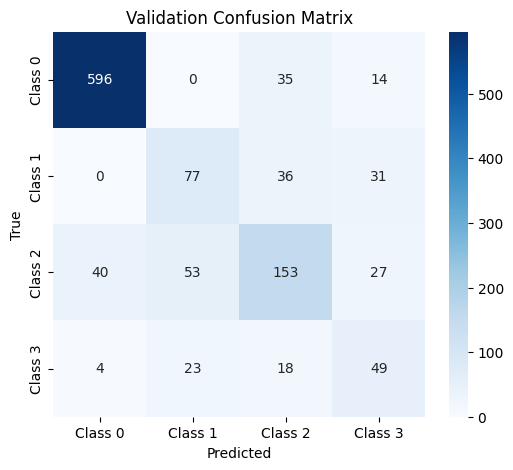

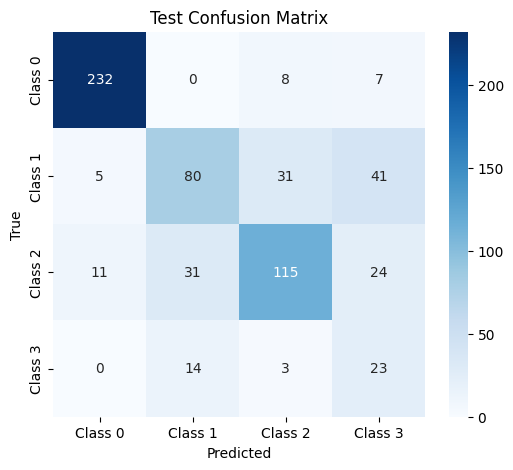

In [16]:
# ==============================
# 🔥 13. CONFUSION MATRIX PLOT
# ==============================
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Class 0","Class 1","Class 2","Class 3"]

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()


plot_confusion_matrix(y_val, y_val_pred, "Validation Confusion Matrix")
plot_confusion_matrix(y_test, y_test_pred, "Test Confusion Matrix")

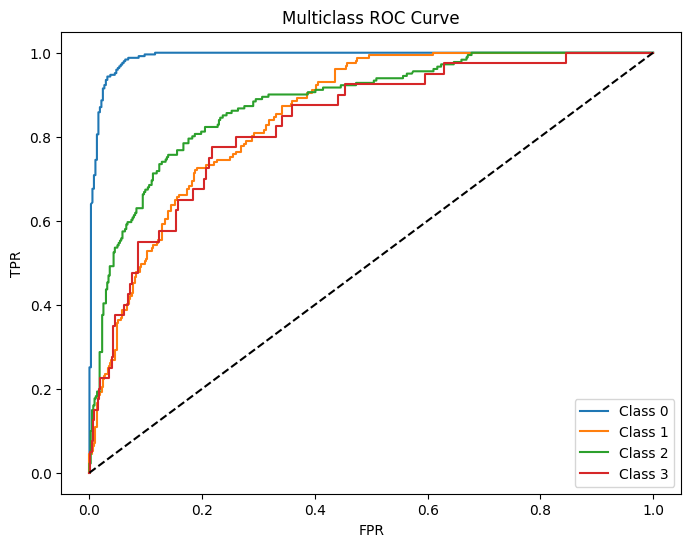

In [17]:
# ==============================
# 🔥 14. MULTICLASS ROC CURVE
# ==============================
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])

plt.figure(figsize=(8,6))

for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()